In [43]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
df=pd.read_csv('/Users/anupamverma/Downloads/online_retail.csv')

In [45]:
df.sample(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
368669,568991,22734,SET OF 6 RIBBONS VINTAGE CHRISTMAS,24,2023-09-29 16:44:00,2.89,18204.0,United Kingdom
29200,538710,22457,NATURAL SLATE HEART CHALKBOARD,6,2022-12-14 10:48:00,2.95,18075.0,United Kingdom
522126,580373,23569,TRADTIONAL ALPHABET STAMP SET,4,2023-12-02 17:06:00,4.95,14788.0,United Kingdom
242318,558330,22355,CHARLOTTE BAG SUKI DESIGN,10,2023-06-28 12:16:00,0.85,12748.0,United Kingdom
430239,573585,15039,SANDALWOOD FAN,15,2023-10-31 14:41:00,1.63,NaN,United Kingdom
195504,553718,84971S,SMALL HEART FLOWERS HOOK,2,2023-05-18 16:14:00,1.63,NaN,United Kingdom
21795,538145,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-09 16:08:00,2.95,15211.0,United Kingdom
312783,564372,20725,LUNCH BAG RED RETROSPOT,30,2023-08-25 09:55:00,1.65,12714.0,France
484688,577536,23396,LE JARDIN BOTANIQUE CUSHION COVER,1,2023-11-20 14:14:00,3.75,15850.0,United Kingdom
20488,538056,22930,BAKING MOULD HEART MILK CHOCOLATE,4,2022-12-09 13:34:00,2.55,17198.0,United Kingdom


### Data Preprocessing and Cleaning

In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 69.3 MB


In [47]:
# Check for Duplicate Entries
df.duplicated().sum()

np.int64(5268)

In [48]:
# View of Actual Duplicate Rows
df[df.duplicated()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2022-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2022-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2022-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2022-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2022-12-01 11:49:00,2.95,17920.0,United Kingdom
...,...,...,...,...,...,...,...,...
541675,581538,22068,BLACK PIRATE TREASURE CHEST,1,2023-12-09 11:34:00,0.39,14446.0,United Kingdom
541689,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,2023-12-09 11:34:00,2.49,14446.0,United Kingdom
541692,581538,22992,REVOLVER WOODEN RULER,1,2023-12-09 11:34:00,1.95,14446.0,United Kingdom
541699,581538,22694,WICKER STAR,1,2023-12-09 11:34:00,2.10,14446.0,United Kingdom


In [49]:
# Drop Duplicate Entries
df.drop_duplicates(inplace=True)

In [50]:
df.duplicated().sum()

np.int64(0)

In [51]:
# Convert InvoiceDate to Datetime
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

In [52]:
# Keep only positive quantities and non-null Customer IDs
df_clean = df[(df['Quantity'] > 0) & (df['CustomerID'].notna())].copy()

# Drop any remaining missing descriptions just in case
df_clean.dropna(subset=['Description'], inplace=True)

In [53]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 392732 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392732 non-null  str           
 1   StockCode    392732 non-null  str           
 2   Description  392732 non-null  str           
 3   Quantity     392732 non-null  int64         
 4   InvoiceDate  392732 non-null  datetime64[us]
 5   UnitPrice    392732 non-null  float64       
 6   CustomerID   392732 non-null  float64       
 7   Country      392732 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 46.2 MB


In [54]:
# Filter out rows where InvoiceNo starts with 'C'
df_clean = df_clean[~df_clean['InvoiceNo'].str.startswith('C', na=False)]

In [55]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 392732 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392732 non-null  str           
 1   StockCode    392732 non-null  str           
 2   Description  392732 non-null  str           
 3   Quantity     392732 non-null  int64         
 4   InvoiceDate  392732 non-null  datetime64[us]
 5   UnitPrice    392732 non-null  float64       
 6   CustomerID   392732 non-null  float64       
 7   Country      392732 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 46.2 MB


In [56]:
# Create a TotalAmount Column
df_clean['TotalAmount'] = (df_clean['Quantity'] * df_clean['UnitPrice']).round(2)

In [57]:
df_clean

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2023-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2023-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2023-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2023-12-09 12:50:00,4.15,12680.0,France,16.60


In [58]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 392732 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392732 non-null  str           
 1   StockCode    392732 non-null  str           
 2   Description  392732 non-null  str           
 3   Quantity     392732 non-null  int64         
 4   InvoiceDate  392732 non-null  datetime64[us]
 5   UnitPrice    392732 non-null  float64       
 6   CustomerID   392732 non-null  float64       
 7   Country      392732 non-null  str           
 8   TotalAmount  392732 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(4)
memory usage: 49.2 MB


In [59]:
df_clean[df_clean['UnitPrice'] <= 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2022-12-05 14:02:00,0.0,12647.0,Germany,0.0
33576,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,2022-12-16 14:36:00,0.0,16560.0,United Kingdom,0.0
40089,539722,22423,REGENCY CAKESTAND 3 TIER,10,2022-12-21 13:45:00,0.0,14911.0,EIRE,0.0
47068,540372,22090,PAPER BUNTING RETROSPOT,24,2023-01-06 16:41:00,0.0,13081.0,United Kingdom,0.0
47070,540372,22553,PLASTERS IN TIN SKULLS,24,2023-01-06 16:41:00,0.0,13081.0,United Kingdom,0.0
56674,541109,22168,ORGANISER WOOD ANTIQUE WHITE,1,2023-01-13 15:10:00,0.0,15107.0,United Kingdom,0.0
86789,543599,84535B,FAIRY CAKES NOTEBOOK A6 SIZE,16,2023-02-10 13:08:00,0.0,17560.0,United Kingdom,0.0
130188,547417,22062,CERAMIC BOWL WITH LOVE HEART DESIGN,36,2023-03-23 10:25:00,0.0,13239.0,United Kingdom,0.0
139453,548318,22055,MINI CAKE STAND HANGING STRAWBERY,5,2023-03-30 12:45:00,0.0,13113.0,United Kingdom,0.0
145208,548871,22162,HEART GARLAND RUSTIC PADDED,2,2023-04-04 14:42:00,0.0,14410.0,United Kingdom,0.0


In [60]:
# Drop Entries with 0 UnitPrice
df_clean = df_clean[df_clean['UnitPrice'] > 0]

In [61]:
df_clean[['Quantity', 'UnitPrice', 'TotalAmount']].describe()

,Quantity,UnitPrice,TotalAmount
count,392692.000000,392692.000000,392692.000000
mean,13.119702,3.125914,22.631500
std,180.492832,22.241836,311.099224
min,1.000000,0.001000,0.000000
25%,2.000000,1.250000,4.950000
50%,6.000000,1.950000,12.450000
75%,12.000000,3.750000,19.800000
max,80995.000000,8142.750000,168469.600000


In [62]:
# Extract features for time-based analysis
df_clean['MonthYear'] = df_clean['InvoiceDate'].dt.to_period('M').astype(str)
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour

In [63]:
df_clean.to_csv('cleaned.csv', index=False)

In [64]:
df_clean

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,MonthYear,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2022-12,8
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2022-12,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2022-12,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2022-12,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2022-12,8
...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2023-12-09 12:50:00,0.85,12680.0,France,10.20,2023-12,12
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2023-12-09 12:50:00,2.10,12680.0,France,12.60,2023-12,12
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2023-12-09 12:50:00,4.15,12680.0,France,16.60,2023-12,12
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2023-12-09 12:50:00,4.15,12680.0,France,16.60,2023-12,12


### Exploratory Data Analysis

/var/folders/fs/kf96xh5s589d5vwpbjc0_4p40000gn/T/ipykernel_2193/1012265529.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='Blues_r')


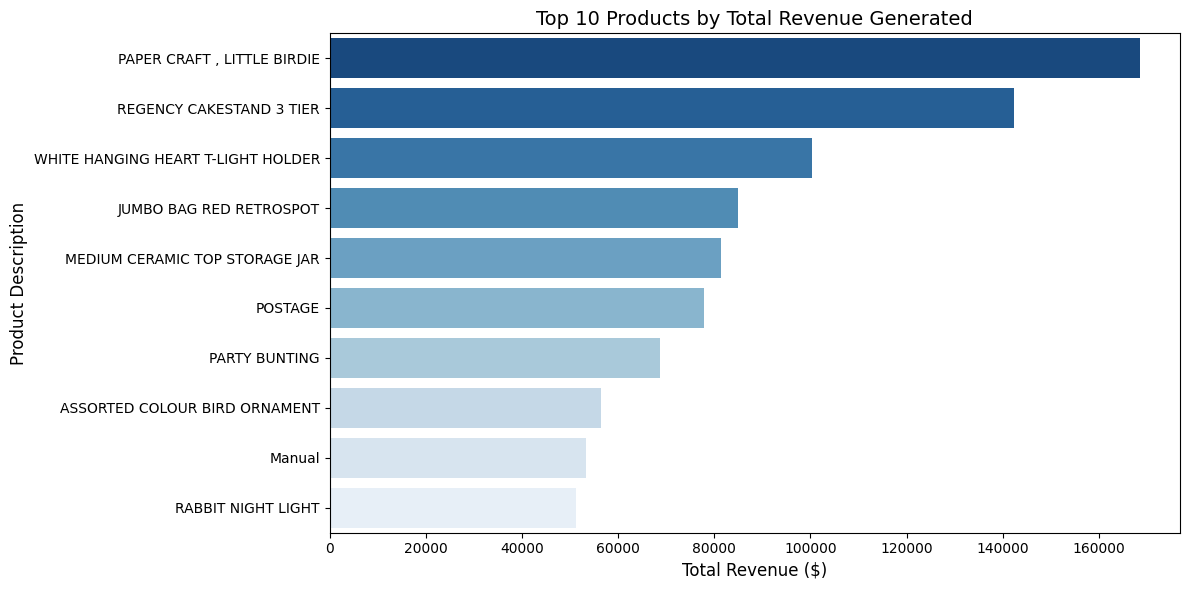

In [65]:
# 1. Top-Selling Products (by Revenue)
plt.figure(figsize=(12, 6))
top_products = df_clean.groupby('Description')['TotalAmount'].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top_products.values, y=top_products.index, palette='Blues_r')
plt.title('Top 10 Products by Total Revenue Generated', fontsize=14)
plt.xlabel('Total Revenue ($)', fontsize=12)
plt.ylabel('Product Description', fontsize=12)
plt.savefig('Top-Selling Products (by Revenue).png', dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

/var/folders/fs/kf96xh5s589d5vwpbjc0_4p40000gn/T/ipykernel_2193/1812160189.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')


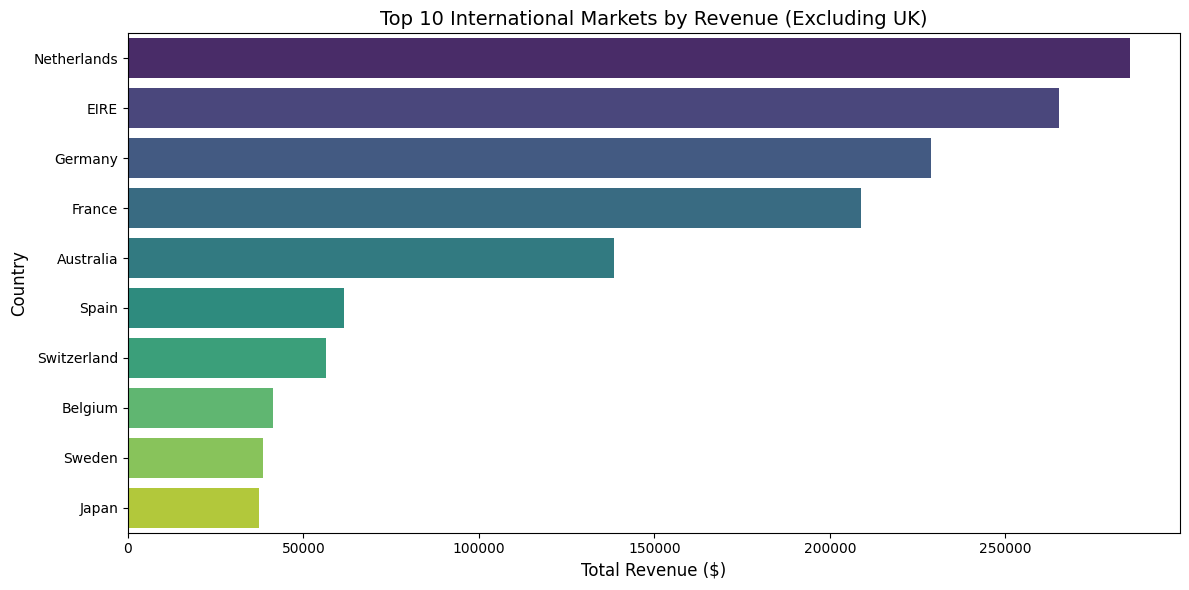

In [66]:
# 2. Country-wise Sales (Excluding UK for better visual contrast because UK dominates over 90% of dataset)
plt.figure(figsize=(12, 6))
# Filter out UK to see international distribution clearly
# top_countries = df_clean.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(10)
top_countries = df_clean[df_clean['Country'] != 'United Kingdom'].groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 10 International Markets by Revenue (Excluding UK)', fontsize=14)
plt.xlabel('Total Revenue ($)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.savefig('Country-wise Sales.png', dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

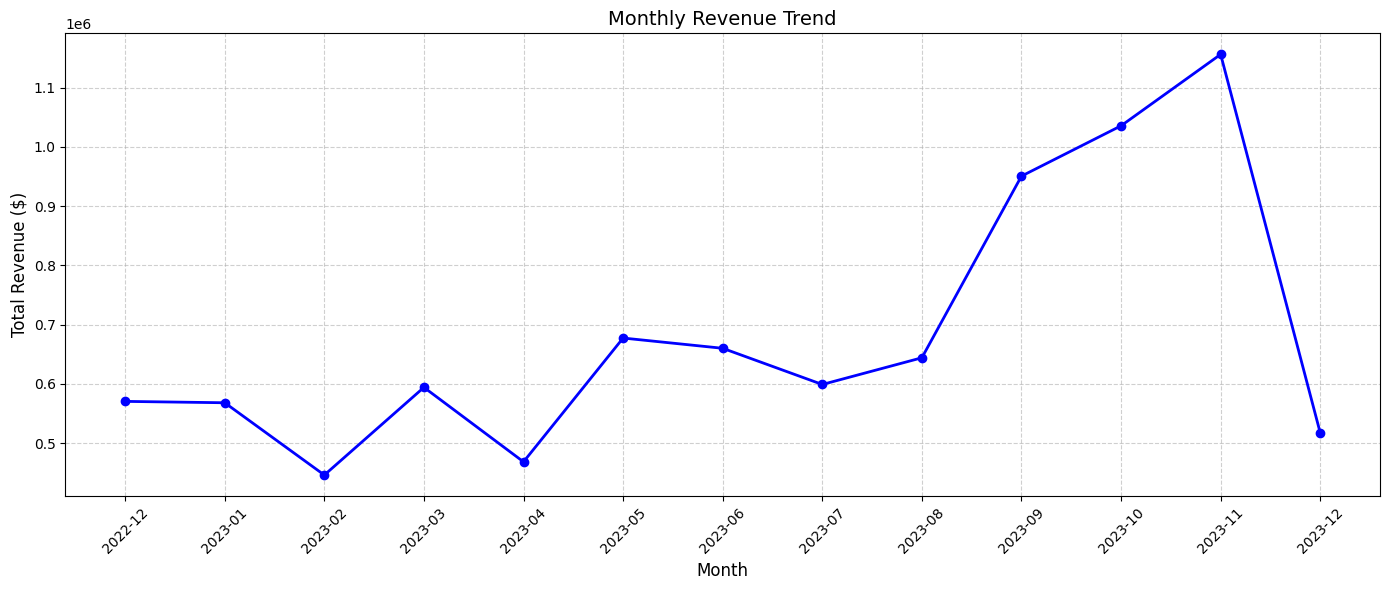

In [67]:
# Monthly Sales Trend
plt.figure(figsize=(14, 6))
monthly_sales = df_clean.groupby('MonthYear')['TotalAmount'].sum()

plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='b', linewidth=2)
plt.title('Monthly Revenue Trend', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('Monthly Sales Trend.png', dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

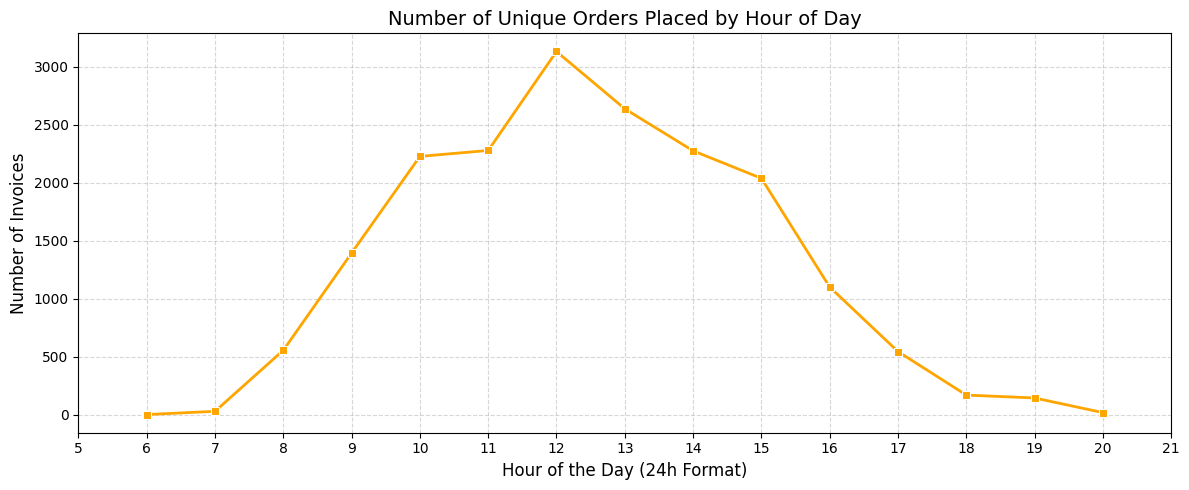

In [68]:
# 4. Customer Purchase Pattern (Hourly Peak Times)
plt.figure(figsize=(12, 5))
hourly_orders = df_clean.groupby('Hour')['InvoiceNo'].nunique()

sns.lineplot(x=hourly_orders.index, y=hourly_orders.values, marker='s', color='orange', linewidth=2)
plt.title('Number of Unique Orders Placed by Hour of Day', fontsize=14)
plt.xlabel('Hour of the Day (24h Format)', fontsize=12)
plt.ylabel('Number of Invoices', fontsize=12)
plt.xticks(range(5, 22))
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('Customer Hourly Purchase Pattern.png', dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

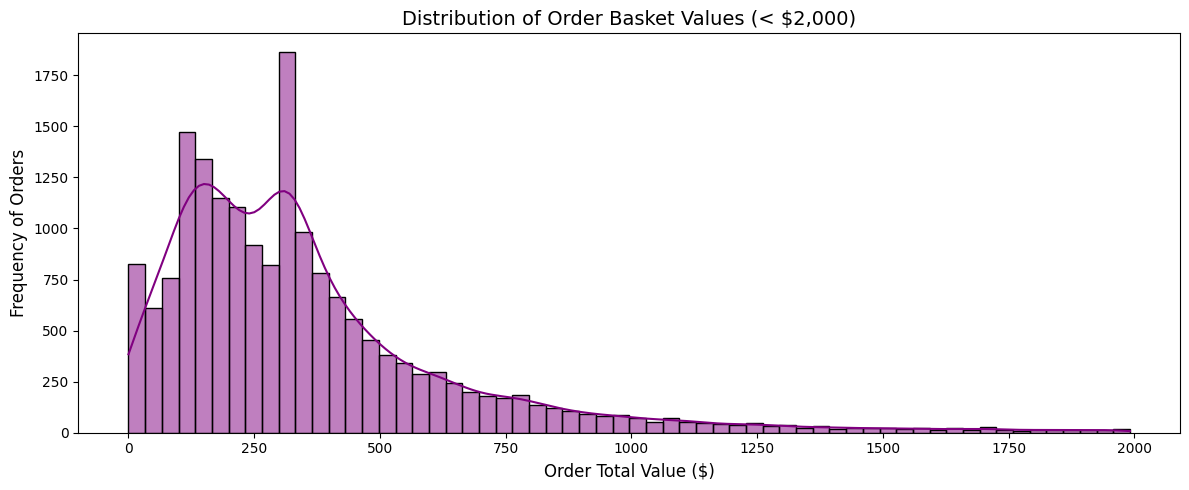

In [69]:
# 5. Revenue Analysis (Distribution of Transaction Value)
plt.figure(figsize=(12, 5))
# Group by Invoice to see how much a typical basket costs
invoice_values = df_clean.groupby('InvoiceNo')['TotalAmount'].sum()

# Filtering out massive wholesale outliers (> $2000) to keep the chart readable
sns.histplot(invoice_values[invoice_values < 2000], bins=60, kde=True, color='purple')
plt.title('Distribution of Order Basket Values (< $2,000)', fontsize=14)
plt.xlabel('Order Total Value ($)', fontsize=12)
plt.ylabel('Frequency of Orders', fontsize=12)
plt.savefig('Revenue Analysis.png', dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

/var/folders/fs/kf96xh5s589d5vwpbjc0_4p40000gn/T/ipykernel_2193/2586217949.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=active_customers.values, y=active_customers.index.astype(str), palette='magma')


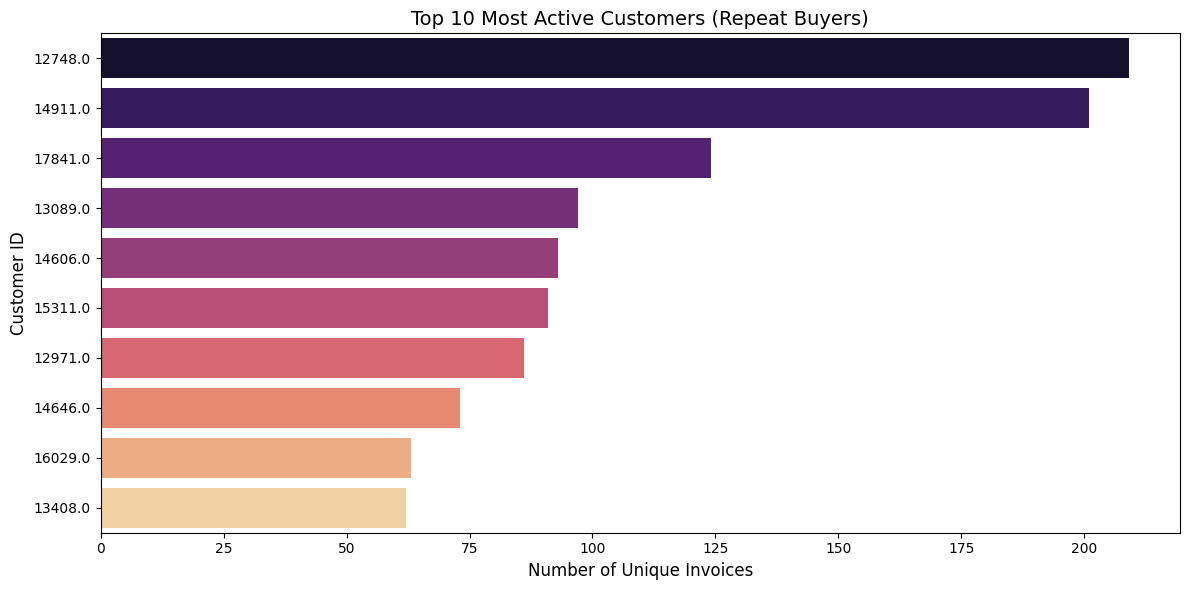

In [70]:
# 6. Most Active Customers (By Number of Orders)
plt.figure(figsize=(12, 6))
# Count unique transactions per customer
active_customers = df_clean.groupby('CustomerID')['InvoiceNo'].nunique().sort_values(ascending=False).head(10)

# Convert indices to strings so matplotlib treats IDs as categories instead of numbers
sns.barplot(x=active_customers.values, y=active_customers.index.astype(str), palette='magma')
plt.title('Top 10 Most Active Customers (Repeat Buyers)', fontsize=14)
plt.xlabel('Number of Unique Invoices', fontsize=12)
plt.ylabel('Customer ID', fontsize=12)
plt.savefig('Most Active Customers.png', dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

### RFM Analysis and Customer Segmentation

In [71]:
# Calculate Recency, Frequency, and Monetary Values
import datetime as dt

referal_date=df_clean['InvoiceDate'].max() + dt.timedelta(days=1)

rfm=df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (referal_date-x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount':'sum'
})

rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo':'Frequency',
    'TotalAmount': 'Monetary'
},inplace=True)       

In [72]:
rfm

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40
...,...,...,...
18280.0,278,1,180.60
18281.0,181,1,80.82
18282.0,8,2,178.05


In [73]:
# Create scores from 1 to 5 using quantiles

# Recency: lower is better 
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1])

# Frequency: higher is better. (We use rank(method='first') to handle duplicate frequencies smoothly)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])

# Monetary: higher is better 
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5])

# Combine scores into a single 3-digit RFM Group 
rfm['RFM_Group'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Group
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,5,115
12347.0,2,7,4310.00,5,5,5,555
12348.0,75,4,1797.24,2,4,4,244
12349.0,19,1,1757.55,4,1,4,414
12350.0,310,1,334.40,1,1,2,112


In [74]:
def map_to_four_segments(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])
    
  
    if r >= 4 and f >= 4:
        return 'High Value Customers'
    

    elif r >= 3 and f >= 3:
        return 'Regular Customers'
    
    
    elif r <= 2 and (f >= 3 or m >= 3):
        return 'At-Risk Customers'
    
   
    else:
        return 'Occasional Customers'

rfm['Segment'] = rfm.apply(map_to_four_segments, axis=1)

print(rfm['Segment'].value_counts())

Segment
Occasional Customers    1491
High Value Customers    1139
At-Risk Customers        887
Regular Customers        821
Name: count, dtype: int64


/var/folders/fs/kf96xh5s589d5vwpbjc0_4p40000gn/T/ipykernel_2193/242593097.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_counts.values, y=segment_counts.index, palette='Set2')


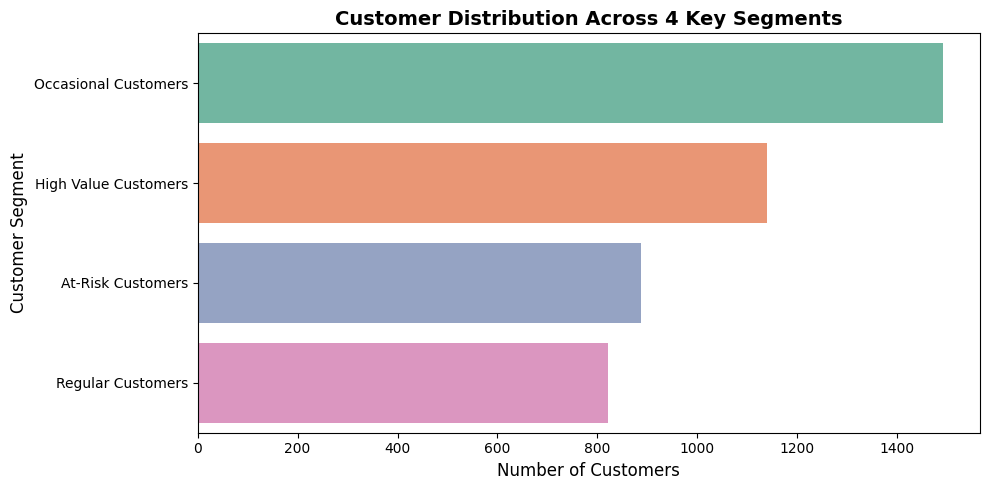

In [75]:
# bar chart visualize final four segments
plt.figure(figsize=(10, 5))
segment_counts = rfm['Segment'].value_counts()

sns.barplot(x=segment_counts.values, y=segment_counts.index, palette='Set2')
plt.title('Customer Distribution Across 4 Key Segments', fontsize=14, fontweight='bold')
plt.xlabel('Number of Customers', fontsize=12)
plt.ylabel('Customer Segment', fontsize=12)
plt.savefig('Customer Distribution Across 4 Key Segments.png', dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

### Customer Clustering

In [76]:
# Check skewness of Recency, Frequency, and Monetary columns
rfm[['Recency', 'Frequency', 'Monetary']].skew()

Recency       1.246048
Frequency    12.067031
Monetary     19.339368
dtype: float64

In [77]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# handle right-skewed distributions
rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].apply(np.log1p, axis=1)

# Scale the data to have a mean of 0 and variance of 1
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

In [78]:
rfm_scaled

array([[ 1.46199281, -0.95521426,  3.7077163 ],
       [-2.03873442,  1.07442519,  1.41490344],
       [ 0.37310424,  0.38630445,  0.72002428],
       ...,
       [-1.21893976, -0.36158278, -1.11333158],
       [-1.65755161,  2.17800394,  0.82281217],
       [-0.03473174,  0.05960547,  0.73752573]], shape=(4338, 3))

In [79]:
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])
rfm_scaled_df.skew()

Recency     -0.379169
Frequency    1.208652
Monetary     0.396599
dtype: float64

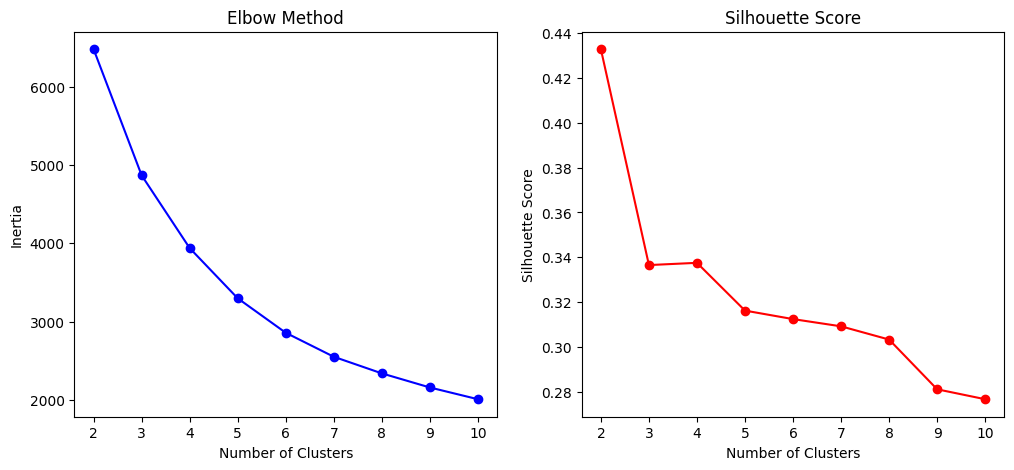

In [80]:
# Elbow Method
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, kmeans.labels_))

# Plot Elbow Curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, 'ro-')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')
plt.show()

In [81]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Analyze cluster characteristics
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)
print(cluster_summary)

         Recency  Frequency  Monetary
Cluster                              
0          12.17      13.75   8088.02
1         181.51       1.32    341.00
2          17.70       2.19    557.32
3          71.64       4.08   1801.78


In [82]:
# Define segment labels based on RFM characteristics
cluster_labels = {
    0: 'High-Value Customer',      # High F, High M, Low R
    1: 'Customer At-Risk',         # High R, Low F, Low M
    2: 'Ocassional Customer',      # Low R, Low F, Low M
    3: 'Regular Customer'          # Medium R, Medium F, Medium M
}

rfm['Segment'] = rfm['Cluster'].map(cluster_labels)

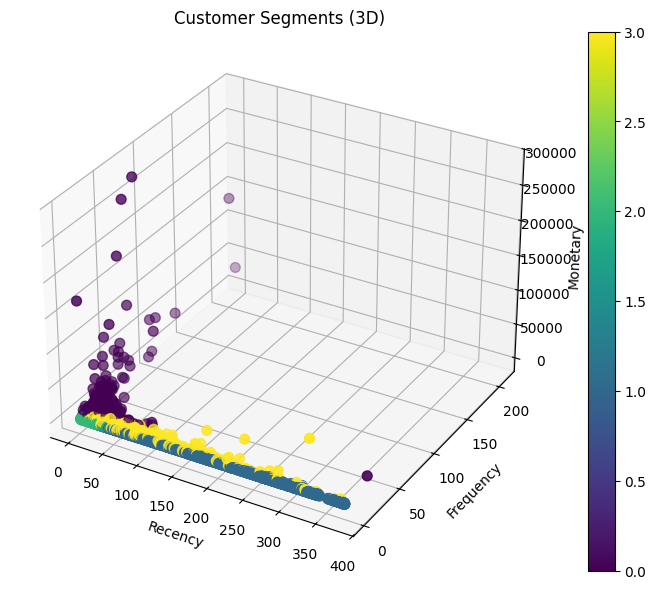

In [83]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(rfm['Recency'], rfm['Frequency'], rfm['Monetary'], 
                     c=rfm['Cluster'], cmap='viridis', s=50)
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
plt.colorbar(scatter)
plt.title('Customer Segments (3D)')
plt.show()

In [84]:
import pickle

with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

### Recommendation System

In [97]:
from sklearn.metrics.pairwise import cosine_similarity

# Load the cleaned Dataset
df_clean=pd.read_csv('cleaned.csv')


# Build Product-User Matrix
item_user_matrix=df_clean.pivot_table(
    index='Description',
    columns='CustomerID',
    values='Quantity',
    aggfunc='sum'
).fillna(0)

# Compute Cosine Similarity between Rows(Description)
item_similarity=cosine_similarity(item_user_matrix)


# Turn Metrix into DataFrame
item_similarity_df=pd.DataFrame(
    item_similarity,
    index=item_user_matrix.index,
    columns=item_user_matrix.index
)

# Export the matrix
with open('item_similarity.pkl', 'wb')as f:
    pickle.dump(item_similarity_df,f)

In [96]:
item_similarity_df

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
Description,,,,,,,,,,,,,,,,,,,,,
4 PURPLE FLOCK DINNER CANDLES,1.000000,0.000000,0.000021,0.000228,0.000000,0.000000,0.020228,0.000000,0.000263,0.063543,...,0.000000,0.001376,0.015917,0.001771,0.000000,0.002852,0.000000,0.013155,0.000000,0.002599
50'S CHRISTMAS GIFT BAG LARGE,0.000000,1.000000,0.003534,0.004001,0.000000,0.020230,0.027477,0.902593,0.119038,0.013384,...,0.000000,0.001726,0.015572,0.018032,0.000000,0.015710,0.000000,0.011238,0.000000,0.029793
DOLLY GIRL BEAKER,0.000021,0.003534,1.000000,0.870965,0.980574,0.006358,0.005311,0.003040,0.001764,0.411471,...,0.000000,0.000044,0.002869,0.344928,0.000000,0.525868,0.000000,0.822964,0.000097,0.006665
I LOVE LONDON MINI BACKPACK,0.000228,0.004001,0.870965,1.000000,0.883987,0.020076,0.004912,0.004051,0.008249,0.382226,...,0.000000,0.001416,0.004198,0.310053,0.000000,0.471772,0.000000,0.749303,0.000000,0.010394
I LOVE LONDON MINI RUCKSACK,0.000000,0.000000,0.980574,0.883987,1.000000,0.000000,0.000000,0.000000,0.000000,0.410712,...,0.000000,0.000000,0.000000,0.347021,0.000000,0.530836,0.000000,0.837176,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZINC T-LIGHT HOLDER STARS SMALL,0.002852,0.015710,0.525868,0.471772,0.530836,0.017043,0.129770,0.015160,0.001125,0.231871,...,0.014745,0.009773,0.108995,0.585205,0.020853,1.000000,0.006385,0.483933,0.002333,0.133134
ZINC TOP 2 DOOR WOODEN SHELF,0.000000,0.000000,0.000000,0.000000,0.000000,0.023415,0.056614,0.000000,0.000368,0.000000,...,0.000000,0.000000,0.013708,0.025044,0.000000,0.006385,1.000000,0.013216,0.000000,0.000000
ZINC WILLIE WINKIE CANDLE STICK,0.013155,0.011238,0.822964,0.749303,0.837176,0.016976,0.022661,0.012949,0.000600,0.373983,...,0.000000,0.023041,0.028676,0.324531,0.000000,0.483933,0.013216,1.000000,0.006986,0.024610


In [98]:
gitignore_content = """__pycache__/
*.pyc
.ipynb_checkpoints/
.env
.streamlit/secrets.toml
"""

with open(".gitignore", "w") as f:
    f.write(gitignore_content)
print("✅ .gitignore has been written successfully!")

✅ .gitignore has been written successfully!
